# FIG4: Inverse-dynamics accuracy of ANNet versus a direct torque-regression MLP

This notebook regenerates manuscript Figure 4 from the packaged data archive `FIG4.zip` or `FIG4`.
The archive must be in the same folder as this notebook. Every plotted value is read from the archive, and the notebook asserts that no value falls outside the axes before saving `FIG4.svg`, `FIG4.pdf` and `FIG4.png`.


All 200 values lie inside the axes (0.01-2 Nm); MLP worse in Joint 1 49 of 50, Joint 2 39 of 50
Saved FIG4.svg
Saved FIG4.pdf


Saved FIG4.png


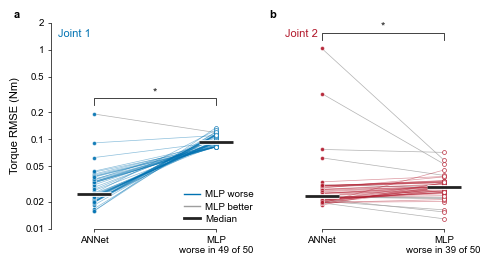

Data provenance:
  trajectories per model and joint = 50
  training samples = 16000
Statistics (primary test, FDR-adjusted):
joint_label             test_name  statistic      p_value  fdr_q_value  median_annet_nm  median_mlp_nm  median_ratio_mlp_over_annet
    Joint 1 Kruskal-Wallis H-test  66.397972 3.684810e-16 7.369620e-16         0.024236       0.093386                     3.853221
    Joint 2 Kruskal-Wallis H-test  10.858646 9.833559e-04 9.833559e-04         0.023413       0.028841                     1.231820


In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Load packaged data. FIG4.zip or FIG4 must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIG4.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIG4")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIG4.zip or FIG4 in the current folder. "
        "Place the data archive in the same folder as FIG4.ipynb."
    )

if DATA_ARCHIVE.is_dir():
    def open_member(name):
        return open(DATA_ARCHIVE / name, "rb")
else:
    _archive = zipfile.ZipFile(DATA_ARCHIVE)

    def open_member(name):
        return _archive.open(name)

rmse_table = pd.read_csv(open_member("fig4_rmse_values.csv"))
stats_table = pd.read_csv(open_member("fig4_statistics.csv"))
metadata = json.load(open_member("fig4_metadata.json"))

# -----------------------------------------------------------------------------
# Fig. 4: paired comparison of ANNet and the direct torque-regression MLP.
# Both models were scored on the same 50 held-out trajectories, so each trajectory is
# one line from its ANNet error (filled marker) to its MLP error (open marker), drawn in
# the joint colour when the MLP is worse and in grey when it is better. Heavy black bars
# are medians. The single asterisk marks a Benjamini-Hochberg-
# adjusted q value of the primary test (fig4_statistics.csv) below 0.05. All inputs come
# from FIG4.zip. All 200 values are drawn, and an assertion verifies that the axis encloses them.
# -----------------------------------------------------------------------------
BLUE, RED, NEUTRAL, GREY = "#0072B2", "#B2182B", "#222222", "0.62"
JOINTS = ["J1", "J2"]; JL = {"J1": "Joint 1", "J2": "Joint 2"}; JC = {"J1": BLUE, "J2": RED}
mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.5, "xtick.major.width": 0.5, "ytick.major.width": 0.5, "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "xtick.major.pad": 2.5, "ytick.major.pad": 2.5, "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "savefig.bbox": "standard", "figure.dpi": 100, "savefig.dpi": 600,
})
T125 = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]
vals = {(j, m): rmse_table[(rmse_table.joint == j) & (rmse_table.model == m)].sort_values("trajectory").rmse_nm.to_numpy(float) for j in JOINTS for m in ("ANNet", "MLP")}
assert all(v.size == 50 for v in vals.values())
allv = np.concatenate(list(vals.values())); lo = max(t for t in T125 if t <= allv.min()); hi = min(t for t in T125 if t >= allv.max())
def star(j): return "*" if float(stats_table.loc[stats_table.joint == j, "fdr_q_value"].iloc[0]) < 0.05 else "ns"

fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.9), sharey=True)
fig.subplots_adjust(left=0.115, right=0.985, top=0.90, bottom=0.19, wspace=0.10)
XA, XM = 0.0, 1.0
for ax, j in zip(axes, JOINTS):
    a, b = vals[(j, "ANNet")], vals[(j, "MLP")]; worse = b > a
    for i in np.argsort(worse):                      # grey (MLP better) drawn first, coloured on top
        ax.plot([XA, XM], [a[i], b[i]], color=JC[j] if worse[i] else GREY, lw=0.5, alpha=0.45 if worse[i] else 0.8, zorder=2)
    ax.scatter(np.full(a.size, XA), a, s=8, color=JC[j], edgecolors="white", linewidths=0.3, alpha=0.9, zorder=3)
    ax.scatter(np.full(b.size, XM), b, s=8, facecolors="white", edgecolors=JC[j], linewidths=0.5, alpha=0.9, zorder=3)
    ma, mb = np.median(a), np.median(b)
    for x, m in ((XA, ma), (XM, mb)):
        ax.plot([x - 0.14, x + 0.14], [m, m], color=NEUTRAL, lw=2.0, solid_capstyle="butt", zorder=6, path_effects=[pe.withStroke(linewidth=3.4, foreground="white")])
    top = max(a.max(), b.max())
    ax.plot([XA, XA, XM, XM], [top * 1.25, top * 1.5, top * 1.5, top * 1.25], color=NEUTRAL, lw=0.6, zorder=6)
    ax.text(0.5, top * 1.55, star(j), ha="center", va="bottom", fontsize=8, color=NEUTRAL)
    ax.text(0.03, 0.97, JL[j], transform=ax.transAxes, ha="left", va="top", fontsize=8, color=JC[j])
    ax.set_yscale("log"); ax.set_ylim(lo, hi); ax.set_xlim(-0.35, 1.35)
    ax.set_xticks([XA, XM]); ax.set_xticklabels(["ANNet", f"MLP\nworse in {int(worse.sum())} of {a.size}"])
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_bounds(XA, XM)
axes[0].yaxis.set_major_locator(FixedLocator([t for t in T125 if lo <= t <= hi])); axes[0].yaxis.set_minor_locator(NullLocator())
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}")); axes[0].set_ylabel("Torque RMSE (Nm)")
axes[1].tick_params(axis="y", length=0); axes[1].spines["left"].set_visible(False)
axes[0].legend(handles=[Line2D([0], [0], color=BLUE, lw=1.0, label="MLP worse"), Line2D([0], [0], color=GREY, lw=1.0, label="MLP better"),
                        Line2D([0], [0], color=NEUTRAL, lw=2.0, label="Median")],
               loc="lower right", frameon=False, handlelength=1.6, handletextpad=0.5, borderaxespad=0.1, labelspacing=0.35)
for label, ax in zip("ab", axes):
    x0, y0, w, h = ax.get_position().bounds
    fig.text(x0 - 0.075 if ax is axes[0] else x0 - 0.02, y0 + h + 0.01, label, fontsize=8, fontweight="bold", ha="left", va="bottom")

# Range check: nothing plotted outside its axes
assert ((allv >= lo) & (allv <= hi)).all()
print(f"All 200 values lie inside the axes ({lo}-{hi} Nm); MLP worse in " + ", ".join(f"{JL[j]} {int((vals[(j, 'MLP')] > vals[(j, 'ANNet')]).sum())} of 50" for j in JOINTS))
for ext in ("svg", "pdf", "png"):
    path = Path(f"FIG4.{ext}")
    fig.savefig(path, facecolor="white")
    print(f"Saved {path}")
plt.show()

print("Data provenance:")
print(f"  trajectories per model and joint = {metadata['test_set']['num_trajectories']}")
print(f"  training samples = {metadata['training_configuration']['training_samples']}")
print("Statistics (primary test, FDR-adjusted):")
print(stats_table[["joint_label", "test_name", "statistic", "p_value", "fdr_q_value",
                   "median_annet_nm", "median_mlp_nm", "median_ratio_mlp_over_annet"]].to_string(index=False))
